# CHAPTER 4 损失函数

## 前言

> 在之前学习机器学习时，我们最先接触的例子——线性回归中，它一上来就使用 MSE（均方误差）作为其损失函数。我们在高中时就学过，这实际上就是用最小二乘法推导出的结果，所以我们可能就没有进一步提出疑问。
>
> 但是，在学习逻辑回归时，突然就出现了一个**交叉熵**的概念。这让我很是困惑，为什么不沿用线性回归中均方差的思想？而且在学习各种损失函数的时候，感觉这些函数看起来很像是被"凑"出来的——平方误差、交叉熵、soft max……它们之间有什么内在联系？
>
> 所以我就产生了一个很深的疑问——**损失函数到底是怎么被构造出来的？**
>
> 直到今天，在我看完 *Understanding Deep Learning*（UDL）的第五章以后，这个问题才终于被解决。UDL 给出了一种全新的视角：**从极大似然估计的角度出发，去理解和推导损失函数**。

> **本章参考**：
> - *Understanding Deep Learning* Chapter 5 Loss Function
> - 知乎：<a href = "https://www.zhihu.com/question/281311791/answer/2343718429" >最大似然估计中的“似然”如何解释？</a>
> - 知乎：<a href = "https://www.zhihu.com/question/281311791/answer/2343718429" >最大似然估计和最小二乘法怎么理解？</a>

## 4.1 极大似然估计

在正式进入损失函数的推导之前，我们需要先掌握一个核心工具——**极大似然估计（Maximum Likelihood Estimation, MLE）**。

先从最直观的例子开始。

### 4.1.1 引例：掷硬币

假设你面前有三枚硬币，它们抛出正面的概率各不相同：

- 硬币 A：抛出正面的概率 $p_A = \frac{2}{5} = 0.4$
- 硬币 B：抛出正面的概率 $p_B = \frac{1}{2} = 0.5$
- 硬币 C：抛出正面的概率 $p_C = \frac{3}{5} = 0.6$

现在，我随机拿起其中**一枚**硬币（你不知道是哪一枚），抛了 $10$ 次，结果有 **$7$ 次正面朝上**。

**问题**：我手中拿的最有可能是哪枚硬币？

---

直觉上，你可能觉得"10次中7次正面"说明这枚硬币抛出正面的概率应该接近 $0.7$。三枚硬币中，硬币 C 的 $p_C=0.6$ 最接近 $0.7$，所以答案是硬币 C。

但我们怎么用数学的语言严谨地描述这个过程？让我们对每一枚硬币，分别计算"抛10次恰好出现7次正面"的概率：

对于一枚正面概率为 $p$ 的硬币，抛 $n=10$ 次出现 $k=7$ 次正面的概率服从**二项分布**：

$$P(k=7 \mid n=10, p) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

分别代入三枚硬币的 $p$ 值：

| 硬币 | $p$ | $P(\text{10次中7次正面})$ |
|:---:|:---:|:---:|
| A | $0.4$ | $\binom{10}{7} \times 0.4^7 \times 0.6^3 \approx 0.0425$ |
| B | $0.5$ | $\binom{10}{7} \times 0.5^7 \times 0.5^3 \approx 0.1172$ |
| C | $0.6$ | $\binom{10}{7} \times 0.6^7 \times 0.4^3 \approx 0.2150$ |

**结论**：硬币 C 产生"10次中7次正面"这个结果的概率最大（$0.2150$），因此它最有可能是我们手中的硬币。

---

这个例子看似简单，但其中蕴含的思想正是极大似然估计的核心：**既然这个结果已经发生了，那么使得这个结果出现概率最大的参数，就是最合理的参数估计。**

### 4.1.2 概率与似然

在深入 MLE 之前，我们必须先厘清两个极易混淆的核心概念：**概率（Probability）** 与 **似然（Likelihood）**。

---

#### 概率（Probability）

**概率**描述的是：**在参数已知的前提下，对不同结果出现的可能性进行度量。**

用数学语言说：给定确定的参数 $\theta$，数据 $x$ 出现的概率为 $P(x \mid \theta)$。这里的 $\theta$ 是**已知常量**，$x$ 是**变量**。

回到掷硬币的例子：已知硬币正面概率 $p=0.5$（参数固定），问抛10次恰好出现7次正面的概率是多少？这就是在**算概率**：

$$P(k=7 \mid n=10, p=0.5) = \binom{10}{7} \times 0.5^7 \times 0.5^3$$

---

#### 似然（Likelihood）

**似然**的思路恰好相反：**在已经观测到数据的前提下，反推什么样的参数最可能产生这组数据。**

用数学语言说：给定已经观测到的数据 $x$，参数 $\theta$ 的似然值为 $L(\theta \mid x)$。这里的数据 $x$ 是**已知常量**，$\theta$ 是**变量**。

回到掷硬币的例子：已经观测到"10次中出现7次正面"这个结果（数据固定），问什么样的 $p$ 值使得这个结果最可能发生？这就是在**算似然**：

$$L(p \mid n=10, k=7) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

这里 $p$ 是自变量，我们可以画出 $L(p)$ 随 $p$ 变化的曲线，找到使似然最大的 $p$。

> 注意：似然函数 $L(\theta \mid x)$ 和概率密度函数 $f(x; \theta)$ 在**形式上完全相同**（都是同一个公式），但**看待的角度截然不同**：
> - 作为 $x$ 的函数（$\theta$ 固定）→ 它是概率密度函数
> - 作为 $\theta$ 的函数（$x$ 固定）→ 它是似然函数
>
> 有些教材使用分号记号 $f(x; \theta)$ 来强调这一点：分号后面的是参数，分号前面的是数据。这种记法在极大似然的语境下尤为清晰——似然函数写作 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$，明确表示 $\theta$ 是变量，$x_i$ 是已知观测值。

---

下面我们画出掷硬币例子中，似然函数 $L(p)$ 随参数 $p$ 变化的曲线：

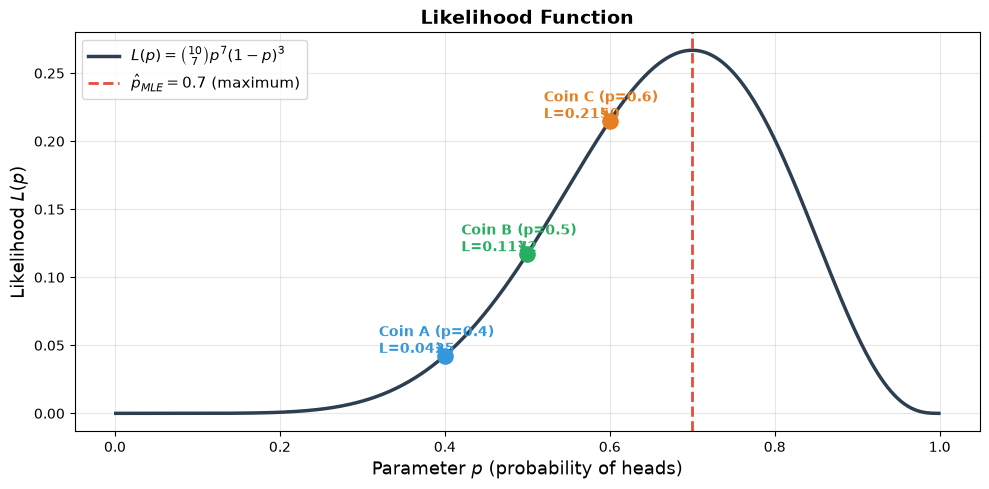

MLE estimate: p_hat = 0.7 (i.e., sample frequency k/n)
This matches intuition: 7 heads in 10 tosses -> the most reasonable estimate for p is 7/10 = 0.7


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# Experiment data: 10 tosses, 7 heads
n, k = 10, 7

# Compute likelihood over p in [0, 1]
p_range = np.linspace(0.001, 0.999, 500)
likelihood = comb(n, k) * (p_range ** k) * ((1 - p_range) ** (n - k))

# Find the maximum
p_mle = k / n  # theoretical maximum at p = k/n = 0.7

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_range, likelihood, '#2C3E50', linewidth=2.5, label=r'$L(p) = \binom{10}{7} p^7 (1-p)^3$')
ax.axvline(x=p_mle, color='#E74C3C', linestyle='--', linewidth=2,
           label=fr'$\hat{{p}}_{{MLE}} = {p_mle}$ (maximum)')

# Mark the three coins
coins = {'A': 0.4, 'B': 0.5, 'C': 0.6}
colors = ['#3498DB', '#27AE60', '#E67E22']
for (name, p_val), c in zip(coins.items(), colors):
    l_val = comb(n, k) * (p_val ** k) * ((1 - p_val) ** (n - k))
    ax.scatter([p_val], [l_val], c=c, s=120, zorder=5)
    ax.annotate(f'Coin {name} (p={p_val})\nL={l_val:.4f}',
                xy=(p_val, l_val), fontsize=10, fontweight='bold', color=c,
                xytext=(p_val - 0.08, l_val + 0.002),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

ax.set_xlabel(r'Parameter $p$ (probability of heads)', fontsize=13)
ax.set_ylabel(r'Likelihood $L(p)$', fontsize=13)
ax.set_title('Likelihood Function', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"MLE estimate: p_hat = {p_mle} (i.e., sample frequency k/n)")
print(f"This matches intuition: 7 heads in 10 tosses -> the most reasonable "
      f"estimate for p is 7/10 = {p_mle}")

### 4.1.3 极大似然估计的思想与形式化

从掷硬币的例子中，我们可以提炼出一个普适的思路：

> **给定一组观测数据，我们想知道什么样的参数 $\theta$ 最有可能产生这组数据。答案就是：使似然函数 $L(\theta)$ 取到最大值的那个 $\hat{\theta}$。**

这个想法和我们训练神经网络的目标是**不谋而合的**——我们有一组训练数据 $\{(x_i, y_i)\}$，有一个模型 $f(x; \phi)$（参数为 $\phi$），我们想要找到一组参数 $\phi$，使得模型对训练数据的"解释能力"最大。

---



#### 形式化定义

设有 $n$ 个**独立同分布**（i.i.d.）的样本 $x_1, x_2, \ldots, x_n$，它们来自某个概率分布，其概率密度函数（连续型）或分布律（离散型）为 $f(x; \theta)$，其中 $\theta$ 是未知参数。

**似然函数（Likelihood Function）** 定义为所有样本的联合概率密度：

$$
\boxed{L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)}
$$

这里使用分号 $f(x; \theta)$ 而不是竖线 $f(x|\theta)$，是为了强调：**$\theta$ 是变量（未知参数），$x_i$ 是固定的（已知观测值）**。$\theta$ 不是一个随机变量，而是一个待估计的确定值。

> **为什么是连乘？** 因为样本之间是独立的，根据概率论，多个独立事件同时发生的概率等于各自概率的乘积：
> $$P(A \cap B) = P(A) \cdot P(B) \quad \text{（当 A 和 B 独立时）}$$
>
> 所以 $n$ 个独立样本的联合概率就是 $n$ 个单独概率的连乘积。

**极大似然估计量（MLE Estimator）** $\hat{\theta}_{\text{MLE}}$ 就是使似然函数取最大值的 $\theta$：

$$
\boxed{\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; L(\theta) = \underset{\theta}{\arg\max} \prod_{i=1}^{n} f(x_i; \theta)}
$$

---




#### 为什么取对数？

在实际计算中，连乘会带来两个严重问题：

1. **数值下溢**：每个 $f(x_i; \theta)$ 都是小于 1 的概率值，$n$ 个这样的值相乘，结果会迅速趋近于 $0$，超出计算机的浮点精度
2. **求导困难**：连乘的导数计算非常繁琐（需要用到乘法法则展开）

**解决方案**：取对数。因为 $\log$ 是单调递增函数，不改变极值点的位置（见图 5.2）。

由此得到**对数似然函数（Log-Likelihood Function）**：

$$
\boxed{\ell(\theta) = \log L(\theta) = \log \prod_{i=1}^{n} f(x_i; \theta) = \sum_{i=1}^{n} \log f(x_i; \theta)}
$$

因此 MLE 的求解等价于：

$$
\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; \ell(\theta) = \underset{\theta}{\arg\max} \sum_{i=1}^{n} \log f(x_i; \theta)
$$

> **注意**：在机器学习中，我们习惯**最小化**损失函数而不是最大化。因此将最大化对数似然取负号，转化为**最小化负对数似然（Negative Log-Likelihood, NLL）**：
>
> $$\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\min} \; \Big[-\sum_{i=1}^{n} \log f(x_i; \theta)\Big]$$
>
> 这就是损失函数的形式！后面我们会反复看到这个模式。

### 4.1.4 极大似然估计的求解步骤

总结起来，MLE 的求解分为以下四个步骤：

| 步骤 | 操作 | 说明 |
|:---:|:---|:---|
| **1** | **写出似然函数** | 根据数据的概率分布，写出联合概率 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$ |
| **2** | **取对数** | 得到对数似然 $\ell(\theta) = \sum_{i=1}^{n} \log f(x_i; \theta)$ |
| **3** | **求导数** | 对 $\ell(\theta)$ 关于 $\theta$ 求偏导，令 $\frac{\partial \ell}{\partial \theta} = 0$，得到似然方程 |
| **4** | **解方程** | 解出 $\hat{\theta}$，即为极大似然估计值 |

> **注意**：当似然函数不可导时（如均匀分布），需要根据具体情况直接分析似然函数的最大值点，不能直接套用求导步骤。

---

## 4.2 从极大似然推导线性回归的损失函数

### 4.2.1 问题设定

考虑一个标准的线性回归问题。我们有 $n$ 个训练样本 $\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_n, y_n)\}$，其中：

- $\mathbf{x}_i \in \mathbb{R}^d$：第 $i$ 个样本的输入特征向量（$d$ 维）
- $y_i \in \mathbb{R}$：第 $i$ 个样本的目标值（标量）

我们用一个线性模型来拟合数据：

$$f(\mathbf{x}_i; \mathbf{w}) = \mathbf{w}^T \mathbf{x}_i$$

其中 $\mathbf{w} \in \mathbb{R}^d$ 是模型的权重参数（为简化记号，这里省略了偏置项 $b$，可以将其吸收进 $\mathbf{w}$ 和 $\mathbf{x}$ 中——在 $\mathbf{x}$ 末尾补一个常数 $1$ 即可）。

### 4.2.2 高斯噪声假设

在现实世界中，我们的线性模型 $\mathbf{w}^T \mathbf{x}_i$ 不可能完美地拟合每一个数据点。真实值 $y_i$ 和预测值 $\mathbf{w}^T \mathbf{x}_i$ 之间总会存在一个偏差——我们称之为**噪声**或**误差**。

我们不再是简单地"让预测值逼近真实值"，而是换一个角度：**对误差的分布做出概率假设**。

具体地，我们假设每个样本的误差 $\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i$ 服从**均值为 0、方差为 $\sigma^2$ 的正态分布**：

$$\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i \sim \mathcal{N}(0, \sigma^2)$$

这个假设意味着什么？

- **均值为 0**：误差在正负两个方向上是"公平"的——模型不会系统性地高估或低估
- **方差 $\sigma^2$ 恒定**（同方差假设 / homoscedasticity）：每个样本点的噪声大小是相同的

在给定输入 $\mathbf{x}_i$ 和参数 $\mathbf{w}$ 的条件下，目标值 $y_i$ 的条件分布为：

$$y_i \mid \mathbf{x}_i; \mathbf{w} \sim \mathcal{N}(\mathbf{w}^T \mathbf{x}_i,\; \sigma^2)$$

即：**在给定 $\mathbf{x}_i$ 的条件下，$y_i$ 服从均值为 $\mathbf{w}^T \mathbf{x}_i$、方差为 $\sigma^2$ 的正态分布。**

<img src="../attachment/图4-1.jpg" width="700" style="display: block; margin: 0 auto;" >


> 如图，中间那条绿色的线（$ \mathbf{w}^T \mathbf{x}_i $）就是就是服从的正态分布的均值，由于方差固定，我们看到构造出相同的，以绿线为中心的正态分布曲线。

其概率密度函数为：

$$\boxed{f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}$$

> **这里 $\mathbf{w}$ 是我们想要求解的未知参数**，$\sigma^2$ 暂时视为已知常数（后面会说明它不影响最终结果）。分号后面的 $\mathbf{w}$ 和 $\sigma^2$ 是变量，分号前面的 $y_i$ 和 $\mathbf{x}_i$ 是已知观测值

### 4.2.3 构建似然函数

假设 $n$ 个样本是**独立**的（这是极大似然估计的关键前提），则似然函数为各样本条件概率密度的连乘积：

$$
\boxed{L(\mathbf{w}) = \prod_{i=1}^{n} f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}
$$

> **注意**：这里 $\mathbf{w}$ 是变量（我们要找的），$\{(\mathbf{x}_i, y_i)\}$ 是已知数据。这正对应于 4.1 节中强调的"似然"视角——数据固定，参数可变。

---

### 4.2.4 从极大似然到最小二乘

接下来取对数，将连乘转化为连加：

$$
\begin{aligned}
\ell(\mathbf{w}) = \log L(\mathbf{w}) &= \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}\right] \\[6pt]
&= \sum_{i=1}^{n} \left[\log\frac{1}{\sqrt{2\pi\sigma^2}} - \frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right] \\[6pt]
&= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**关键一步**：现在我们要找到 $\hat{\mathbf{w}}_{\text{MLE}}$，使得对数似然 $\ell(\mathbf{w})$ 最大化：

$$\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\max} \; \ell(\mathbf{w})$$

观察 $\ell(\mathbf{w})$ 的结构：
- 第一项 $-\frac{n}{2}\log(2\pi\sigma^2)$ 与 $\mathbf{w}$ **无关**，可以去掉
- 第二项 $-\frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2$ 中，因子 $-\frac{1}{2\sigma^2}$ 是负的常数，**不影响极值点位置**

因此：

$$
\begin{aligned}
\hat{\mathbf{w}}_{\text{MLE}} &= \underset{\mathbf{w}}{\arg\max} \; \left[-\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\max} \; \left[-\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\min} \; \sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**我们得到了什么？**

$$
\boxed{\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}
$$

取均值后就是我们熟知的 **MSE（Mean Squared Error）**：

$$\boxed{\mathcal{L}(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}$$

> 在线性回归中，MSE 损失函数**不是凭空捏造的**，它来自于三个假设：
>
> 1. **误差服从正态分布**：$\epsilon \sim \mathcal{N}(0, \sigma^2)$
> 2. **样本独立同分布**（i.i.d.）
> 3. **极大似然估计**：寻找让数据出现概率最大的参数
>
> 在这三个前提下，最大化似然**等价于**最小化平方误差。这就是 MSE 作为线性回归损失函数的**概率论基础**。

### 4.2.5 同方差假设下的噪声方差 $\sigma^2$ 的极大似然估计

在 4.2.4 节中，我们通过极大化对数似然得到了权重 $\mathbf{w}$ 的估计，期间我们**将 $\sigma^2$ 视为已知常数**，因此包含 $\sigma^2$ 的项被当作与 $\mathbf{w}$ 无关而直接丢弃。

但一个自然的问题是：**$\sigma^2$ 本身能否也从数据中估计出来？** 答案是肯定的——我们可以对 $\sigma^2$ 同样做极大似然估计，使参数估计完整。

---



#### 同时估计 $\mathbf{w}$ 和 $\sigma^2$

回到 4.2.4 节中写出的对数似然函数，这次我们将其视为 $\mathbf{w}$ 和 $\sigma^2$ 的**二元函数**：

$$
\ell(\mathbf{w}, \sigma^2) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
$$

> **记号约定**：将 $\sigma^2$ 视为一个整体参数（即参数是"方差"而非"标准差"），这样求导更加方便。

---



将 $\ell$ 对 $\sigma^2$ 求偏导（将 $\mathbf{w}$ 视为常量）：

$$
\begin{aligned}
\frac{\partial \ell}{\partial \sigma^2}
&= \frac{\partial}{\partial \sigma^2}\left[-\frac{n}{2}\log\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= -\frac{n}{2} \cdot \frac{1}{\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---



令 $\frac{\partial \ell}{\partial \sigma^2} = 0$：

$$
-\frac{n}{2} \cdot \frac{1}{\hat{\sigma}^2} + \frac{1}{2(\hat{\sigma}^2)^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2 = 0
$$

两边同乘 $2(\hat{\sigma}^2)^2$：

$$
-n \cdot \hat{\sigma}^2 + \sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2 = 0
$$

整理得：

$$
\boxed{\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}
$$

---



这个结果非常直观：

> **噪声方差 $\sigma^2$ 的极大似然估计，就是模型残差的均方值——即所有样本上预测误差的平方的平均。**

换句话说，当我们用 MSE 作为损失函数训练完模型后，**MSE 的值本身就是 $\sigma^2$ 的极大似然估计**。这也解释了为什么在训练线性回归模型时，我们通常用训练集上的 MSE 来评估模型的拟合质量——它不仅衡量了"预测误差"，还从概率角度给出了噪声大小的估计。

---

#### 完整的参数估计

将 $\mathbf{w}$ 和 $\sigma^2$ 的估计放在一起：

$$
\begin{aligned}
\hat{\mathbf{w}}_{\text{MLE}} &= \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2 \\[4pt]
\hat{\sigma}^2_{\text{MLE}} &= \frac{1}{n}\sum_{i=1}^{n} \big(y_i - \hat{\mathbf{w}}_{\text{MLE}}^T \mathbf{x}_i\big)^2
\end{aligned}
$$

> **注意顺序**：先由最小化平方误差得到 $\hat{\mathbf{w}}_{\text{MLE}}$（与 $\sigma^2$ 无关），再将其代入残差公式得到 $\hat{\sigma}^2_{\text{MLE}}$。$\mathbf{w}$ 的估计不依赖于 $\sigma^2$，但 $\sigma^2$ 的估计依赖于 $\hat{\mathbf{w}}$。

### 4.2.6 异方差假设（Heteroscedasticity）：当方差不再是常数

在 4.2.2 节中，我们做了一个重要假设：所有样本的噪声 $\epsilon_i$ 拥有**相同的方差** $\sigma^2$（同方差假设 / homoscedasticity）。也就是说，无论输入 $\mathbf{x}_i$ 取什么值，模型预测的不确定性都是一样的。

但在现实世界中，这个假设往往不成立。例如：

- 预测房价时，高价房产的价格波动远大于低价房产
- 预测收入时，高收入人群的收入方差远大于低收入人群
- 物理测量中，传感器的精度可能随被测值的增大而降低

**异方差**（heteroscedasticity）就是指：**噪声的方差 $\sigma^2$ 依赖于输入 $\mathbf{x}$，即 $\sigma^2 = \sigma^2(\mathbf{x})$。**

下面我们用一个简单的线性回归例子来直观感受同方差和异方差的区别。


真实参数:    y = 2.000x + 1.000
OLS  拟合:   y = 1.770x + 1.510   (同方差假设，所有点等权)
WLS  拟合:   y = 2.094x + 0.999   (异方差假设，权重 = 1/σ²)
OLS  总误差: |Δw| + |Δb| = 0.230 + 0.510 = 0.740
WLS  总误差: |Δw| + |Δb| = 0.094 + 0.001 = 0.095
→ WLS 显著优于 OLS！异方差假设让拟合更接近真实参数。


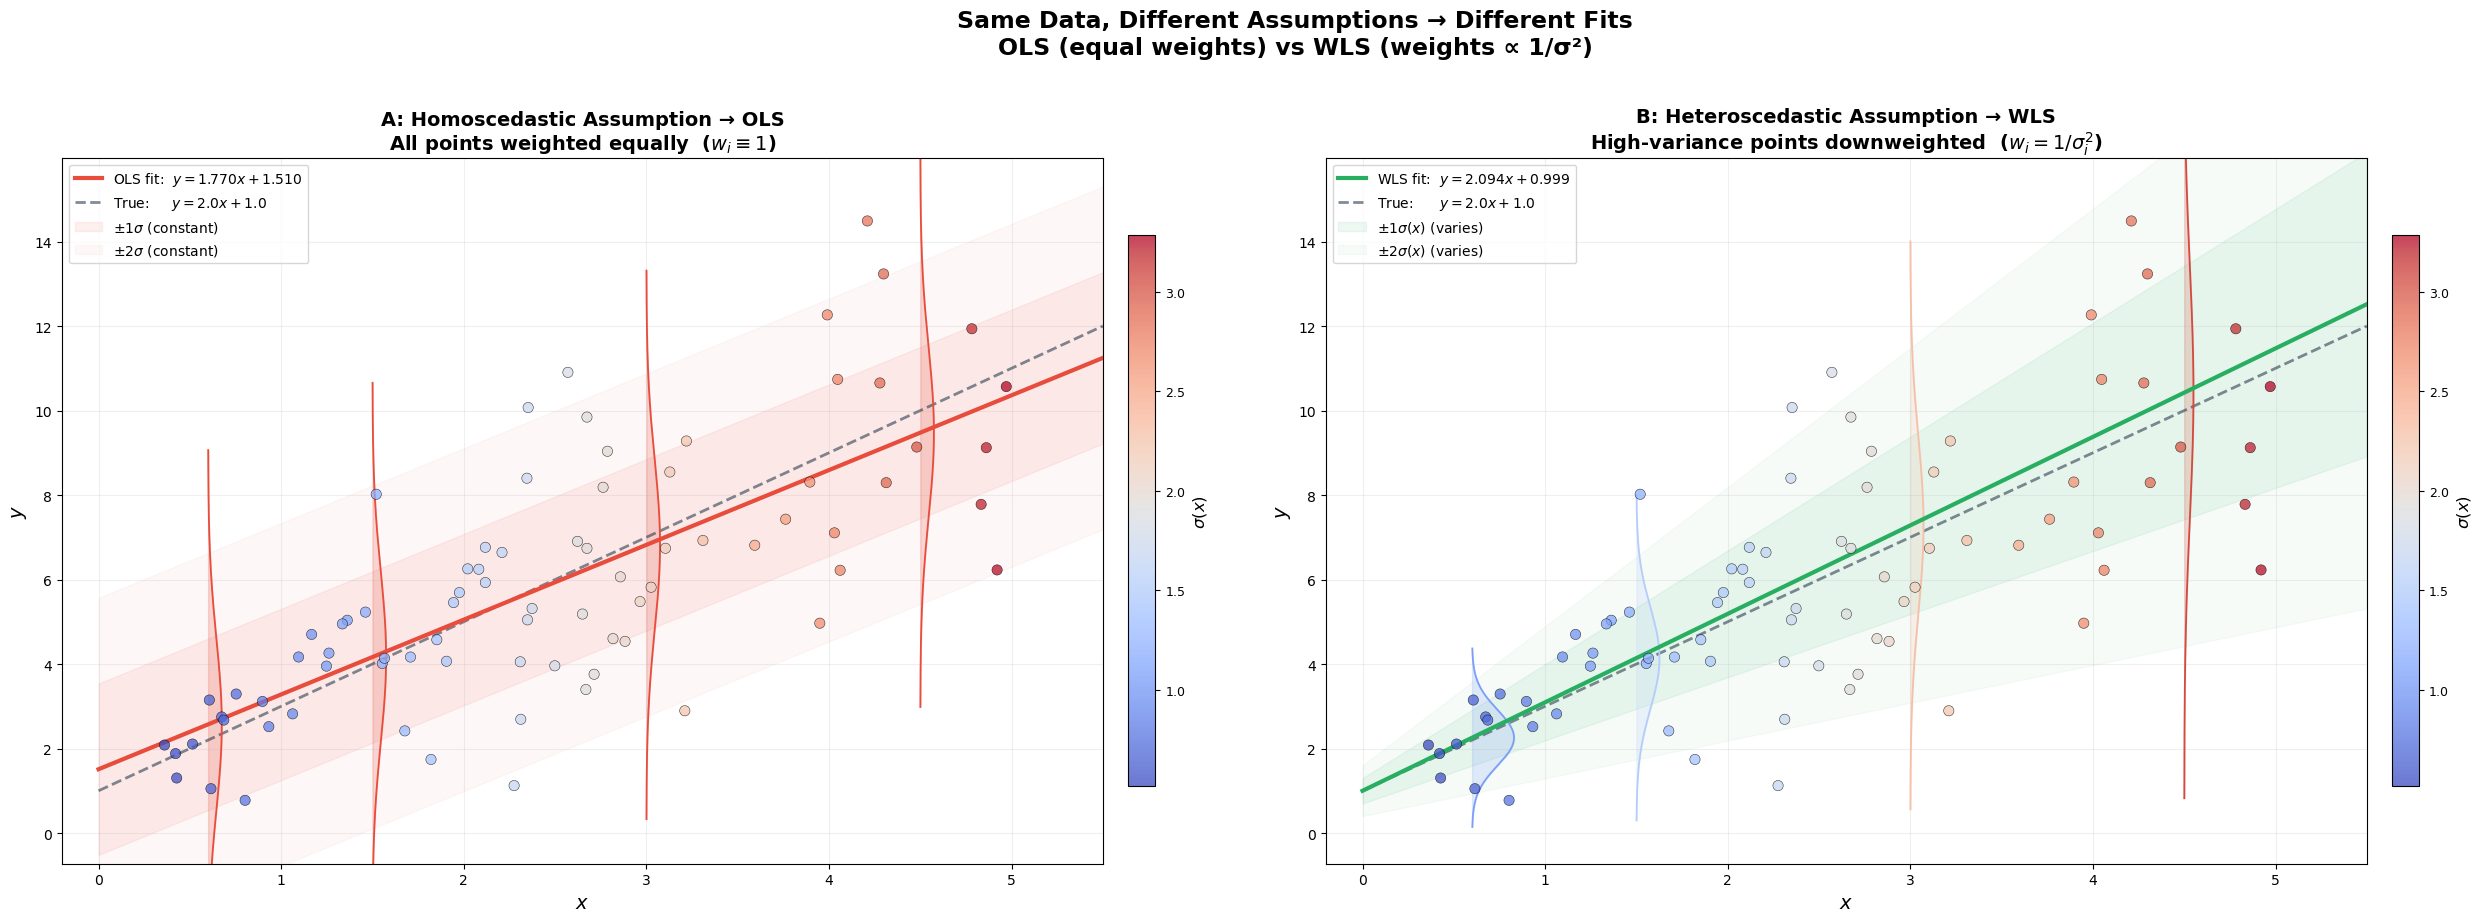

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(2)

# ============================================================
# 生成异方差数据 —— 典型的"漏斗"形态
# σ(x) 随 x 线性增长（非对称），打破 OLS = WLS 的对称性
# ============================================================
n = 80
x = np.random.uniform(0.3, 5.0, n)
w_true, b_true = 2.0, 1.0

# 异方差噪声: σ(x) = 0.3 + 0.6x —— x 越大，噪声越大
sigma_x = 0.3 + 0.6 * x
noise = np.random.randn(n) * sigma_x
y = w_true * x + b_true + noise

# ============================================================
# 两种拟合方法
# ============================================================
# 1. 普通最小二乘 OLS（同方差假设）
w_ols, b_ols = np.polyfit(x, y, 1)

# 2. 加权最小二乘 WLS（异方差假设，权重 ∝ 1/σ²）
weights = 1.0 / sigma_x**2
w_wls, b_wls = np.polyfit(x, y, 1, w=weights)

print(f"真实参数:    y = {w_true:.3f}x + {b_true:.3f}")
print(f"OLS  拟合:   y = {w_ols:.3f}x + {b_ols:.3f}   (同方差假设，所有点等权)")
print(f"WLS  拟合:   y = {w_wls:.3f}x + {b_wls:.3f}   (异方差假设，权重 = 1/σ²)")
print(f"OLS  总误差: |Δw| + |Δb| = {abs(w_ols-w_true):.3f} + {abs(b_ols-b_true):.3f} = {abs(w_ols-w_true)+abs(b_ols-b_true):.3f}")
print(f"WLS  总误差: |Δw| + |Δb| = {abs(w_wls-w_true):.3f} + {abs(b_wls-b_true):.3f} = {abs(w_wls-w_true)+abs(b_wls-b_true):.3f}")
print(f"→ WLS 显著优于 OLS！异方差假设让拟合更接近真实参数。")

# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(26, 9))

x_line = np.linspace(0, 5.5, 300)
sigma_line = 0.3 + 0.6 * x_line   # 异方差 σ(x) 曲线
x_demo = [0.6, 1.5, 3.0, 4.5]     # 高斯截面位置

# ================================================================
# Panel A: 同方差假设 → OLS 拟合（等权）
# ================================================================
ax = axes[0]

# 按局部方差着色
sc = ax.scatter(x, y, c=sigma_x, cmap='coolwarm', s=55, alpha=0.75,
                edgecolors='black', linewidth=0.4, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.78, pad=0.02)
cbar.set_label(r'$\sigma(x)$', fontsize=12)
cbar.ax.tick_params(labelsize=9)

# OLS 拟合线
y_ols = w_ols * x_line + b_ols
ax.plot(x_line, y_ols, '#E74C3C', linewidth=3.0, zorder=3,
        label=fr'OLS fit:  $y = {w_ols:.3f}x + {b_ols:.3f}$')

# 真实直线
ax.plot(x_line, w_true * x_line + b_true, '#2C3E50', linewidth=2.0,
        linestyle='--', alpha=0.6, zorder=2,
        label=fr'True:     $y = {w_true:.1f}x + {b_true:.1f}$')

# 同方差 ±1σ / ±2σ 带（等宽）
sigma_const = np.std(y - (w_ols * x + b_ols))
ax.fill_between(x_line,
                y_ols - sigma_const, y_ols + sigma_const,
                alpha=0.08, color='#E74C3C', label=r'$\pm 1\sigma$ (constant)')
ax.fill_between(x_line,
                y_ols - 2*sigma_const, y_ols + 2*sigma_const,
                alpha=0.04, color='#E74C3C', label=r'$\pm 2\sigma$ (constant)')

# 等宽高斯截面
for xp in x_demo:
    yp = w_ols * xp + b_ols
    yv = np.linspace(yp - 3.2*sigma_const, yp + 3.2*sigma_const, 150)
    pv = norm.pdf(yv, yp, sigma_const)
    xc = xp + pv * 0.38
    ax.fill_betweenx(yv, xp, xc, alpha=0.20, color='#E74C3C')
    ax.plot(xc, yv, '#E74C3C', linewidth=1.3)

ax.set_xlabel('$x$', fontsize=14); ax.set_ylabel('$y$', fontsize=14)
ax.set_title('A: Homoscedastic Assumption → OLS\n'
             r'All points weighted equally  ($w_i \equiv 1$)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(-0.2, 5.5); ax.set_ylim(y.min() - 1.5, y.max() + 1.5)
ax.grid(True, alpha=0.2)

# ================================================================
# Panel B: 异方差假设 → WLS 拟合（加权）
# ================================================================
ax = axes[1]

sc2 = ax.scatter(x, y, c=sigma_x, cmap='coolwarm', s=55, alpha=0.75,
                 edgecolors='black', linewidth=0.4, zorder=5)
cbar2 = plt.colorbar(sc2, ax=ax, shrink=0.78, pad=0.02)
cbar2.set_label(r'$\sigma(x)$', fontsize=12)
cbar2.ax.tick_params(labelsize=9)

# WLS 拟合线
y_wls = w_wls * x_line + b_wls
ax.plot(x_line, y_wls, '#27AE60', linewidth=3.0, zorder=3,
        label=fr'WLS fit:  $y = {w_wls:.3f}x + {b_wls:.3f}$')

# 真实直线
ax.plot(x_line, w_true * x_line + b_true, '#2C3E50', linewidth=2.0,
        linestyle='--', alpha=0.6, zorder=2,
        label=fr'True:      $y = {w_true:.1f}x + {b_true:.1f}$')

# 异方差 ±1σ / ±2σ 带（宽度随 x 变化）
ax.fill_between(x_line,
                y_wls - sigma_line, y_wls + sigma_line,
                alpha=0.08, color='#27AE60', label=r'$\pm 1\sigma(x)$ (varies)')
ax.fill_between(x_line,
                y_wls - 2*sigma_line, y_wls + 2*sigma_line,
                alpha=0.04, color='#27AE60', label=r'$\pm 2\sigma(x)$ (varies)')

# 变宽高斯截面（颜色深浅随方差大小变化）
for xp in x_demo:
    yp = w_wls * xp + b_wls
    sp = 0.3 + 0.6 * abs(xp)
    yv = np.linspace(yp - 3.2*sp, yp + 3.2*sp, 150)
    pv = norm.pdf(yv, yp, sp)
    xc = xp + pv * 0.38
    cc = plt.cm.coolwarm(sp / sigma_x.max())
    ax.fill_betweenx(yv, xp, xc, alpha=0.20, color=cc)
    ax.plot(xc, yv, color=cc, linewidth=1.3)

ax.set_xlabel('$x$', fontsize=14); ax.set_ylabel('$y$', fontsize=14)
ax.set_title('B: Heteroscedastic Assumption → WLS\n'
             r'High-variance points downweighted  ($w_i = 1/\sigma_i^2$)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(-0.2, 5.5); ax.set_ylim(y.min() - 1.5, y.max() + 1.5)
ax.grid(True, alpha=0.2)

fig.suptitle('Same Data, Different Assumptions → Different Fits\n'
             'OLS (equal weights) vs WLS (weights ∝ 1/σ²)',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('heteroscedasticity_OLS_WLS.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 加权最小二乘（WLS）——方差已知时的异方差处理

4.2 节的核心结论是：在同方差假设（$\sigma_i^2 \equiv \sigma^2$）下，$\sigma^2$ 虽然未知，但作为一个标量可以从 $\mathbf{w}$ 的优化中解耦——先求 $\hat{\mathbf{w}}$（OLS），再从残差估计 $\hat{\sigma}^2$。

现在考虑异方差情形：每个样本的噪声方差 $\sigma_i^2$ 不同。如果这些 $\sigma_i^2$ **是已知的**，极大似然估计会给出什么？

---


### 4.3.1 模型设定与推导

条件分布：

$$
y_i \mid \mathbf{x}_i; \mathbf{w} \sim \mathcal{N}\big(\mathbf{w}^\top \mathbf{x}_i,\; \sigma_i^2\big)
$$

其中每个 $\sigma_i^2$ 是**已知常数**（不参与优化）。概率密度函数：

$$
f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma_i^2) = \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right\}
$$

构建似然函数，取对数：

$$
\begin{aligned}
\ell(\mathbf{w})
&= \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right\}\right] \\[4pt]
&= -\frac{1}{2}\sum_{i=1}^{n}\log(2\pi\sigma_i^2) - \sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}
\end{aligned}
$$

由于 $\sigma_i^2$ 已知，第一项是常数。最大化 $\ell(\mathbf{w})$ 等价于最小化第二项（去掉常数因子 $1/2$）：

$$
\boxed{\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{\sigma_i^2}}
$$

这就是**加权最小二乘（Weighted Least Squares, WLS）**。与 OLS 的唯一区别：每个样本的平方误差被其方差 $\sigma_i^2$ 的倒数加权。

> **权重直觉**：$\sigma_i^2$ 大（噪声大、不可靠）→ 权重 $1/\sigma_i^2$ 小 → 压低该点影响；$\sigma_i^2$ 小（精确）→ 权重 $1/\sigma_i^2$ 大 → 放大该点影响。

---


### 4.3.2 WLS 的根本局限

WLS的局限在于：**$\sigma_i^2$ 必须提前已知。**

在现实中，方差随 $\mathbf{x}$ 变化的规律几乎不可能提前知道——如果知道，那说明你已经把问题理解透了，也就不需要做回归了。WLS 假设你手握方差的"标准答案"，这在实际中极少成立。

> **核心矛盾**：WLS 之所以简洁，是因为它回避了最难的问题——方差函数 $\sigma^2(\mathbf{x})$ 本身怎么来？同方差下的 OLS 能估计 $\sigma^2$，是因为方差结构退化到了最简形式（一个常数）。一旦方差随 $\mathbf{x}$ 变化，WLS 就要求这个变化规律提前已知，而它自己没有能力从数据中学习这个规律。

这就引出了下一节的核心问题：**能不能让模型自己从数据中学习方差函数？**

## 4.4 深度学习视角——让模型同时学习均值与方差

WLS 的根本局限在于：$\sigma_i^2$ 必须提前已知。**要想从数据中同时学习均值函数和方差函数，必须把方差也变成模型的参数。** 这就需要对方差函数做参数化，将均值参数和方差参数**联合优化**。

---

### 4.4.1 参数化方差函数：双输出神经网络

最自然的做法是用一个**双输出神经网络**——输入 $\mathbf{x}$，同时输出均值 $\mu(\mathbf{x})$ 和方差 $\sigma^2(\mathbf{x})$。若需要拟合多段线区域，需要在中间添加隐藏层h

---

#### 网络架构

以最简单的线性回归为例：

<img src="../attachment/图4-2.jpg" width="700" style="display: block; margin: 0 auto;" >

数学上：

$$
\begin{aligned}
\mathbf{h} &= \mathbf{W}_h \mathbf{x} + \mathbf{b}_h &&\text{(隐藏层)} \\[4pt]
\hat{\mu} &= \mathbf{w}_\mu^\top \mathbf{h} + b_\mu &&\text{(均值输出，恒等激活)} \\[4pt]
\hat{\sigma}^2 &= \exp\!\big(\mathbf{w}_\sigma^\top \mathbf{h} + b_\sigma\big) &&\text{(方差输出，}\exp\text{激活}\text{)}
\end{aligned}
$$

> **为什么用 $\exp$？** 方差必须为正（$\sigma^2 > 0$）。$\exp$ 将任意实数映射到 $(0, \infty)$，是保证方差合法的最简洁方式。


---

### 4.4.2 完整的负对数似然

回到异方差的对数似然。这次第一项 $-\frac{1}{2}\sum\log\sigma_i^2$ **必须保留**，因为它包含 $\boldsymbol{\theta}$：

$$
\ell(\mathbf{w}, \boldsymbol{\theta}) = -\frac{1}{2}\sum_{i=1}^{n}\log(2\pi\sigma_i^2) - \sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}
$$

取负号，得到**负对数似然损失**：

$$
\boxed{\mathcal{L}(\mathbf{w}, \boldsymbol{\theta}) = \sum_{i=1}^{n} \left[\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2} + \frac{1}{2}\log\sigma_i^2\right] + \text{const}}
$$

> **对比 WLS（4.3 节）**：WLS 中 $\sigma_i^2$ 是已知常数，$\log\sigma_i^2$ 项被当作常数丢掉，损失只剩加权残差。这里 $\sigma_i^2$ 依赖 $\boldsymbol{\theta}$，$\log\sigma_i^2$ **必须保留**——它是方差参数的梯度来源。



---

### 4.4.3 应用：不确定性估计

Full NLL 在深度学习中的一个重要应用是**不确定性估计（Uncertainty Estimation）**。模型同时输出预测值 $\hat{y}$ 和预测方差 $\hat{\sigma}^2$：

- 数据噪声小的区域 → 模型自动输出小的 $\hat{\sigma}^2$（"我很确定"）
- 数据噪声大的区域 → 模型自动输出大的 $\hat{\sigma}^2$（"我不太确定"）

这让模型不仅能回答「预测值是多少」，还能回答「对这个预测有多大的把握」——在自动驾驶、医疗诊断等安全关键场景中，后者往往比前者更重要。

## 4.5 从极大似然推导二分类的损失函数

在 4.2 节中，我们从正态分布的极大似然估计出发，重新推导出了 MSE 损失函数。但当我们面对分类问题时，目标变量 $y$ 不再是连续实数，而是离散的类别标签。本节讨论二分类问题，即 $y \in \{0, 1\}$。

> **关键转换**：模型不再直接预测 $y$ 的类别，而是预测 $y$ 的**概率分布**。具体来说，模型输出 $y=1$ 的概率 $\lambda$，损失函数则鼓励模型对真实标签给出尽可能高的概率。

### 4.5.1 Bernoulli 分布：描述二值结果

二值输出的自然选择是 **Bernoulli 分布**（也称 0-1 分布）。它定义在 $\{0, 1\}$ 上，只有一个参数 $\lambda \in [0, 1]$，表示 $y=1$ 的概率：

$$
\boxed{Pr(y \mid \lambda) = (1-\lambda)^{1-y} \cdot \lambda^{y}}
$$

这个紧凑写法蕴含了两个情形：

$$
Pr(y \mid \lambda) =
\begin{cases}
1 - \lambda, & y = 0 \\[4pt]
\lambda, & y = 1
\end{cases}
$$

### 4.5.2 Logistic Sigmoid：将任意实数映射为概率

我们已经确定模型需要输出参数 $\lambda \in [0,1]$。然而，神经网络 $f[\mathbf{x}, \phi]$ 的输出可以是任意实数 $\mathbb{R}$。直接将网络输出当作概率是有问题的——实数范围超出了 $[0,1]$。

为解决这个问题，我们在网络输出上套一层函数，将其"压缩"到 $[0,1]$ 区间。这个函数就是 **Logistic Sigmoid**（逻辑 S 型函数）：

$$
\boxed{\text{sig}[z] = \frac{1}{1 + \exp[-z]}}
$$

因此，我们令：

$$
\lambda = \text{sig}[f[\mathbf{x}, \phi]]
$$

这样一来，网络输出任意实数 → sigmoid 压缩 → 得到合法的概率 $\lambda \in (0,1)$。

### 4.5.3 从极大似然推导二分类交叉熵损失函数

#### Step 1：写出似然函数

给定 $n$ 个独立样本 $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$，其中 $y_i \in \{0, 1\}$。设模型预测的概率为 $\lambda_i = \text{sig}[f[\mathbf{x}_i, \phi]]$。

根据 Bernoulli 分布，每个样本的似然为：

$$
Pr(y_i \mid \lambda_i) = (1 - \lambda_i)^{1 - y_i} \cdot \lambda_i^{y_i}
$$

由于样本独立，总似然为：

$$
\boxed{L(\phi) = \prod_{i=1}^{n} Pr(y_i \mid \lambda_i) = \prod_{i=1}^{n} \Big[(1 - \text{sig}[f[\mathbf{x}_i, \phi]])^{1 - y_i} \cdot \text{sig}[f[\mathbf{x}_i, \phi]]^{y_i}\Big]}
$$

---

#### Step 2 & 3：取对数，构造负对数似然

取对数（最大化 → 最小化取负号）：

$$
\begin{aligned}
\ell(\phi) = \log L(\phi) &= \sum_{i=1}^{n} \Big[(1 - y_i) \log\big(1 - \text{sig}[f[\mathbf{x}_i, \phi]]\big) + y_i \log\big(\text{sig}[f[\mathbf{x}_i, \phi]]\big)\Big]
\end{aligned}
$$

**负对数似然损失函数**（损失函数  = 取负号）：

$$
\boxed{\mathcal{L}_{\text{BCE}}(\phi) = -\ell(\phi) = -\sum_{i=1}^{n} \Big[(1 - y_i) \log\big(1 - \text{sig}[f[\mathbf{x}_i, \phi]]\big) + y_i \log\big(\text{sig}[f[\mathbf{x}_i, \phi]]\big)\Big]}
$$

这就是著名的 **二分类交叉熵损失（Binary Cross-Entropy Loss, BCE）**。

由此，我们看出，交叉熵损失函数，是伯努利概率分布在极大似然推导下的必然结果，并不是一个拼凑出来的结果。

### 4.5.4 推理与决策边界

训练完成后，模型输出 $\lambda = \text{sig}[f[\mathbf{x}, \hat{\phi}]]$ 代表 $P(y=1 \mid \mathbf{x})$。要做"是/否"的二选一决策，通常以 $0.5$ 为界：

$$
\hat{y} = \begin{cases}
1, & \lambda > 0.5 \quad (\text{等价于 } f[\mathbf{x}, \hat{\phi}] > 0) \\[4pt]
0, & \lambda < 0.5 \quad (\text{等价于 } f[\mathbf{x}, \hat{\phi}] < 0)
\end{cases}
$$

> **决策边界的几何意义**：$\lambda = 0.5$ 对应 $f[\mathbf{x}, \hat{\phi}] = 0$（因为 $\text{sig}[0] = 0.5$）。因此，网络输出的**零等值面**就是决策边界。

## 4.6 从极大似然推导多分类的损失函数

在二分类问题中，输出空间只有两个取值 $\{0, 1\}$。本节推广到多分类问题：目标 $y$ 可以取 $K$ 个不同类别之一，即 $y \in \{1, 2, \ldots, K\}$。

### 4.6.1 Categorical 分布：描述多类结果

多分类输出的自然选择是 **Categorical 分布**（类别分布），它有 $K$ 个参数 $\lambda_1, \lambda_2, \ldots, \lambda_K$，分别代表每个类别的概率：

$$
\boxed{Pr(y = k \mid \lambda_1, \ldots, \lambda_K) = \lambda_k}
$$

参数满足两个约束：

$$
\text{(1) } \lambda_k \in [0, 1] \quad \forall k \qquad \text{(2) } \sum_{k=1}^{K} \lambda_k = 1
$$

> **写成 one-hot 形式**：设 $\mathbf{y} = (y_1, \ldots, y_K)$ 为 one-hot 向量（真实类别对应位置为 1，其余为 0），则 Categorical 分布的概率可紧凑地写为：
>
> $$Pr(\mathbf{y} \mid \boldsymbol{\lambda}) = \prod_{k=1}^{K} \lambda_k^{\,y_k}$$

### 4.6.2 Softmax 函数：将 $K$ 个实数映射为概率向量

神经网络需要输出 $K$ 个值并满足概率约束。**Softmax 函数**正是为此而设计。它接收一个 $K$ 维向量 $\mathbf{z}$，输出一个同维的概率向量：

$$
\boxed{\text{softmax}_k[\mathbf{z}] = \frac{\exp[z_k]}{\sum_{k'=1}^{K} \exp[z_{k'}]}}
$$


因此，对于有 $K$ 个输出的网络 $f[\mathbf{x}, \phi] = (f_1, f_2, \ldots, f_K)$，模型预测的类别概率为：

$$
Pr(y = k \mid \mathbf{x}, \phi) = \text{softmax}_k[f[\mathbf{x}, \phi]] = \frac{\exp[f_k[\mathbf{x}, \phi]]}{\sum_{k'=1}^{K} \exp[f_{k'}[\mathbf{x}, \phi]]}
$$

### 4.6.3 从极大似然推导多分类交叉熵损失函数


#### Step 1：写出似然函数

给定 $n$ 个独立样本 $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$，其中 $y_i \in \{1, 2, \ldots, K\}$。定义 $y_i$ 的 one-hot 表示 $\mathbf{t}_i$（真实类别对应位置为 1）。

对于第 $i$ 个样本，模型输出 $K$ 个 logits：$f_k[\mathbf{x}_i, \phi]$（$k = 1, \ldots, K$）。经 softmax 后得到概率：

$$\lambda_{ik} = \text{softmax}_k[f[\mathbf{x}_i, \phi]] = \frac{\exp[f_k[\mathbf{x}_i, \phi]]}{\sum_{k'=1}^{K} \exp[f_{k'}[\mathbf{x}_i, \phi]]}$$

根据 Categorical 分布，该样本的似然贡献为：

$$
Pr(y_i = k \mid \mathbf{x}_i, \phi) = \lambda_{ik}
$$

等价于 one-hot 形式：

$$
Pr(\mathbf{t}_i \mid \mathbf{x}_i, \phi) = \prod_{k=1}^{K} \big(\lambda_{ik}\big)^{t_{ik}}
$$

由于 $t_{ik}$ 仅在真实类别处为 1，其余为 0，这等价于 **取出真实类别对应的概率**：$\lambda_{i, y_i}$。

---



#### Step 2 & 3：取对数，构造负对数似然

总似然函数：

$$
L(\phi) = \prod_{i=1}^{n} \prod_{k=1}^{K} \big(\lambda_{ik}\big)^{t_{ik}} = \prod_{i=1}^{n} \lambda_{i, y_i}
$$

取对数：

$$
\ell(\phi) = \log L(\phi) = \sum_{i=1}^{n} \sum_{k=1}^{K} t_{ik} \log \lambda_{ik} = \sum_{i=1}^{n} \log \lambda_{i, y_i}
$$

**负对数似然损失函数**：

$$
\boxed{\mathcal{L}_{\text{CE}}(\phi) = -\sum_{i=1}^{n} \log \lambda_{i, y_i} = -\sum_{i=1}^{n} \log \left(\frac{\exp[f_{y_i}[\mathbf{x}_i, \phi]]}{\sum_{k=1}^{K} \exp[f_k[\mathbf{x}_i, \phi]]}\right)}
$$

这就是 **多分类交叉熵损失（Cross-Entropy Loss, CE）**。

---



在代码实现中，通常展开为：

$$
\boxed{\mathcal{L}_{\text{CE}}(\phi) = -\sum_{i=1}^{n} \Big( f_{y_i}[\mathbf{x}_i, \phi] - \log\sum_{k=1}^{K} \exp\big[f_k[\mathbf{x}_i, \phi]\big] \Big)}
$$

## 4.7 总结：损失函数的统一框架

在这一章的学习中，我们从引入极大似然估计开始，分别对线性回归，逻辑回归（二分类问题），多分类问题的损失函数进行了推导。

1. 在之前学习机器学习的损失函数的时候，为我们提供第一直觉的就是线性回归中的均方差损失函数。通过最小化预测值与真实值之间的差距来对参数进行优化。但是极大似然给了我们从**最大化发生概率**的角度来理解参数优化的目标。

2. 在之前的学习中，我们都明白，神经网络的输出 $y_i$ 是一个实数值，而极大似然估计要最大化的是事件发生的概率。也就是说，我们希望找到一个函数 $g$ 来完成这个任务。实际上就是将输出的 $y_i$ 转换成一个输出的概率。然后再为这个概率寻找一个合适的概率分布，利用极大似然估计去表示优化的目标。

    （1）对于线性回归的网络我们认为其误差服从正态分布。对于均值的预测输出，我们使用了恒等激活函数。而对于方差的输出，为了满足其恒为正数的需求，我们采用了 $\exp$ 激活函数，将神经网络输出的任意实数域映射到 $(0, \infty)$ 区间中。

    （2）对于二分类问题，我们认为其输出概率服从伯努利分布。我们希望神经网络的输出是 $y_i = 1$ 事件发生的概率 $\lambda$ ，自然就会考虑到 $sigmoid$ 激活函数，将任意实数域映射到 $(0,1)$ 的概率分布区间中。
    
    <img src="../attachment/图4-3.jpg" width="700" style="display: block; margin: 0 auto;" >

    （3）对于多分类问题，我们考虑其服从分类分布，为了满足神经网络输出值域范围是 $(0,1)$ ，且具有归一性（各类别的发生概率合为一）。$softmax$ 函数是我们的首选，它的输出自然地满足了分类分布的所有要求。

    <img src="../attachment/图4-4.jpg" width="700" style="display: block; margin: 0 auto;" >

从上面的三个例子中，我们的确明白了，激活函数就是建立起神经网络数值输出到概率输出的一座桥梁。在输出层的激活函数和隐藏层的激活函数所做的事情是不一样的。当然转成概率输出也只是极大似然的第一步，最为关键的还是选择合适的概率分布。